In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)

In [18]:

file_path = "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/Crime_Clean.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(494426, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13307269,JG540388,12/14/2023 12:01:00 AM,001XX S TROY ST,0820,THEFT,$500 AND UNDER,VACANT LOT / LAND,False,False,1124,11.0,28.0,27.0,06,1155371.0,1898949.0,2023,12/22/2023 03:41:15 PM,41.878520,-87.704974,"(41.878519796, -87.704973708)"
1,11339480,JB295964,06/06/2018 05:03:00 PM,003XX S HOMAN AVE,1330,CRIMINAL TRESPASS,TO LAND,SIDEWALK,True,False,1134,11.0,28.0,27.0,26,1153781.0,1897987.0,2018,06/13/2018 04:15:47 PM,41.875912,-87.710838,"(41.875911762, -87.710837503)"
2,2856772,HJ520501,07/25/2003 04:45:00 PM,001XX E DELAWARE PL,0870,THEFT,POCKET-PICKING,HOTEL/MOTEL,False,False,1833,18.0,42.0,8.0,06,1177786.0,1906673.0,2003,02/28/2018 03:56:25 PM,41.899235,-87.622436,"(41.899235024, -87.622436193)"
3,11912488,JC535868,11/14/2019 08:00:00 AM,031XX S SHIELDS AVE,1110,DECEPTIVE PRACTICE,BOGUS CHECK,"SCHOOL, PRIVATE, BUILDING",False,False,915,9.0,11.0,34.0,11,1174469.0,1884050.0,2019,12/08/2019 03:57:40 PM,41.837231,-87.635295,"(41.837230767, -87.635295009)"
4,10941360,JA259248,05/11/2017 11:18:00 AM,008XX N LOCKWOOD AVE,1821,NARCOTICS,MANU/DEL:CANNABIS 10GM OR LESS,SIDEWALK,True,False,1524,15.0,37.0,25.0,18,1140872.0,1904987.0,2017,02/10/2018 03:50:01 PM,41.895368,-87.758063,"(41.895367769, -87.75806298)"


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/pp/g4gxxt1n4msf_38rzlmv0c9w0000gn/T/ipykernel_32512/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [20]:
df['Hour'] = df['Date'].dt.hour
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

### Crime Type Distribution

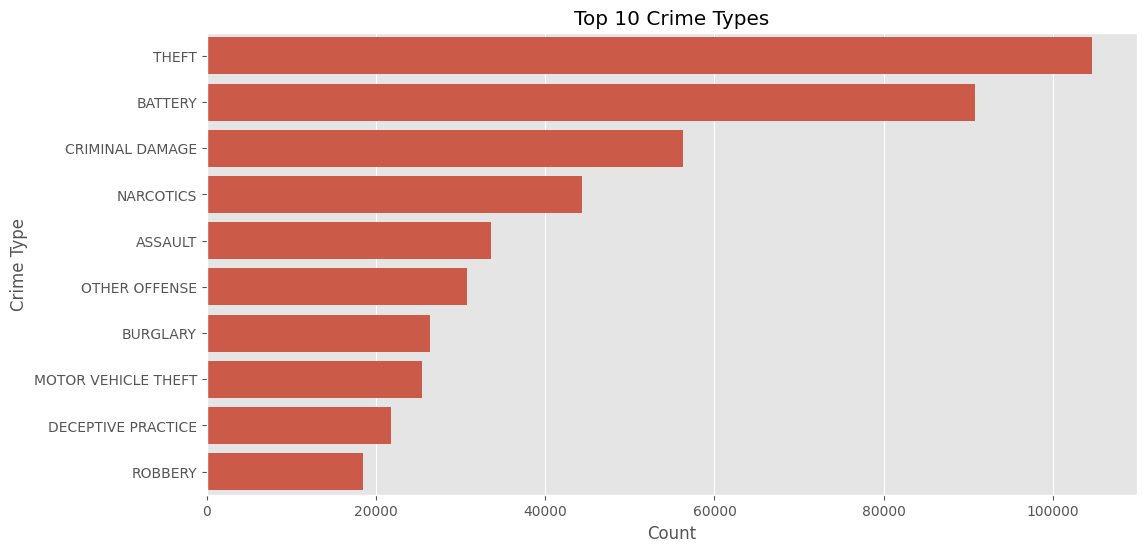

In [21]:
top_crimes = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_crimes.values, y=top_crimes.index)

plt.title("Top 10 Crime Types")
plt.xlabel("Count")
plt.ylabel("Crime Type")

plt.show()

#Arrest Rate Analysis

In [22]:
df['Arrest'].value_counts()

Arrest
False    369934
True     124492
Name: count, dtype: int64

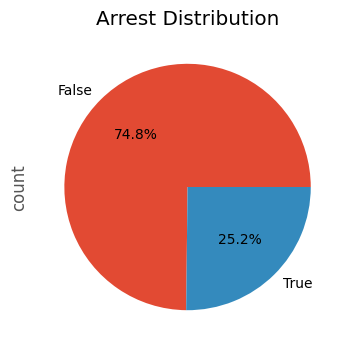

In [23]:
plt.figure(figsize=(6,4))
df['Arrest'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Arrest Distribution")
plt.show()

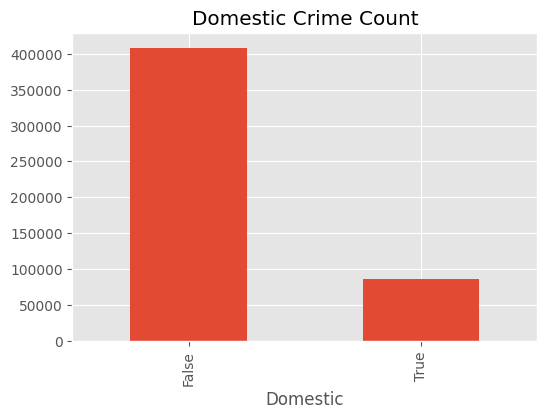

In [24]:
plt.figure(figsize=(6,4))
df['Domestic'].value_counts().plot(kind='bar')
plt.title("Domestic Crime Count")
plt.show()

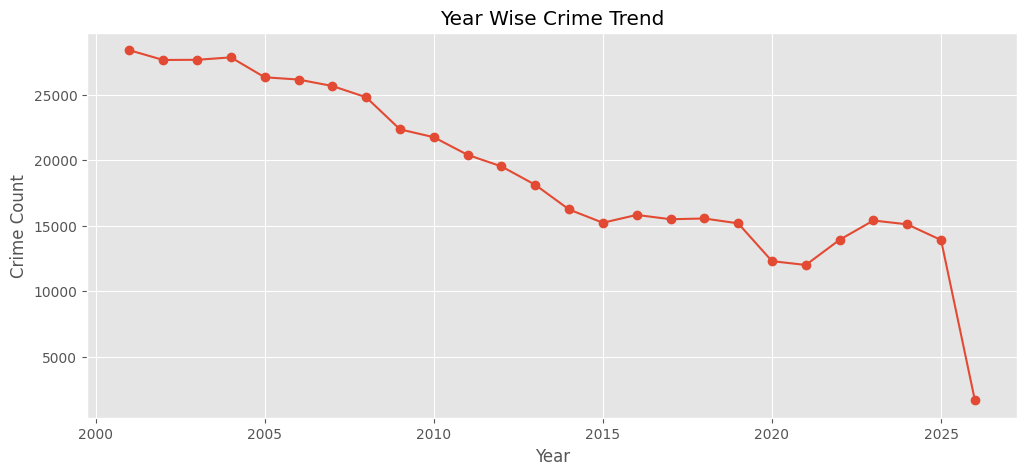

In [25]:
year_trend = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_trend.plot(kind='line', marker='o')

plt.title("Year Wise Crime Trend")
plt.xlabel("Year")
plt.ylabel("Crime Count")

plt.show()

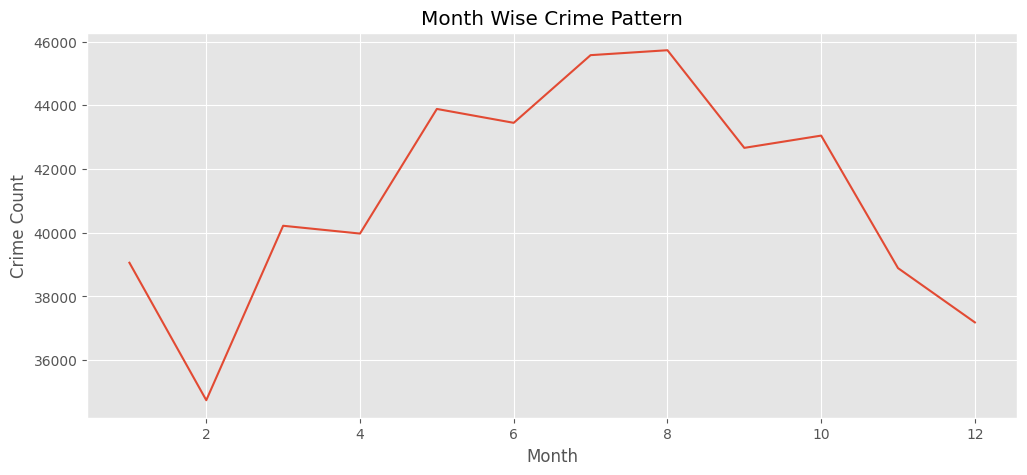

In [26]:
month_trend = df['Month'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=month_trend.index, y=month_trend.values)

plt.title("Month Wise Crime Pattern")
plt.xlabel("Month")
plt.ylabel("Crime Count")

plt.show()

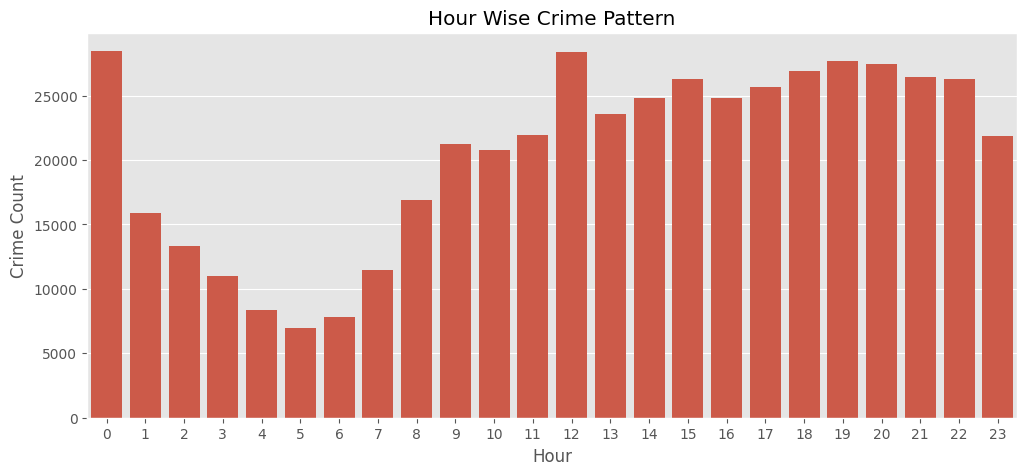

In [27]:
hour_trend = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.barplot(x=hour_trend.index, y=hour_trend.values)

plt.title("Hour Wise Crime Pattern")
plt.xlabel("Hour")
plt.ylabel("Crime Count")

plt.show()

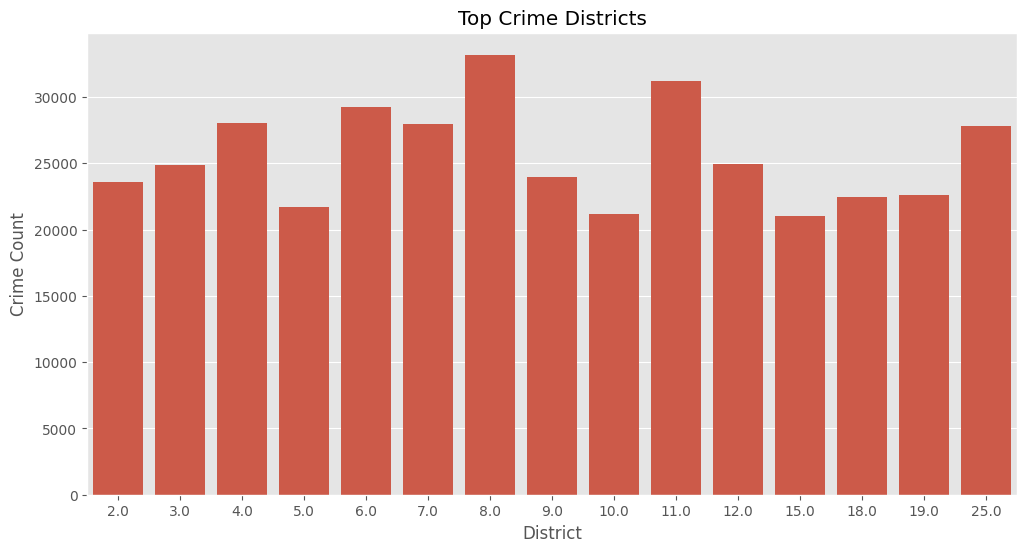

In [28]:
district_trend = df['District'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=district_trend.index, y=district_trend.values)

plt.title("Top Crime Districts")
plt.xlabel("District")
plt.ylabel("Crime Count")

plt.show()

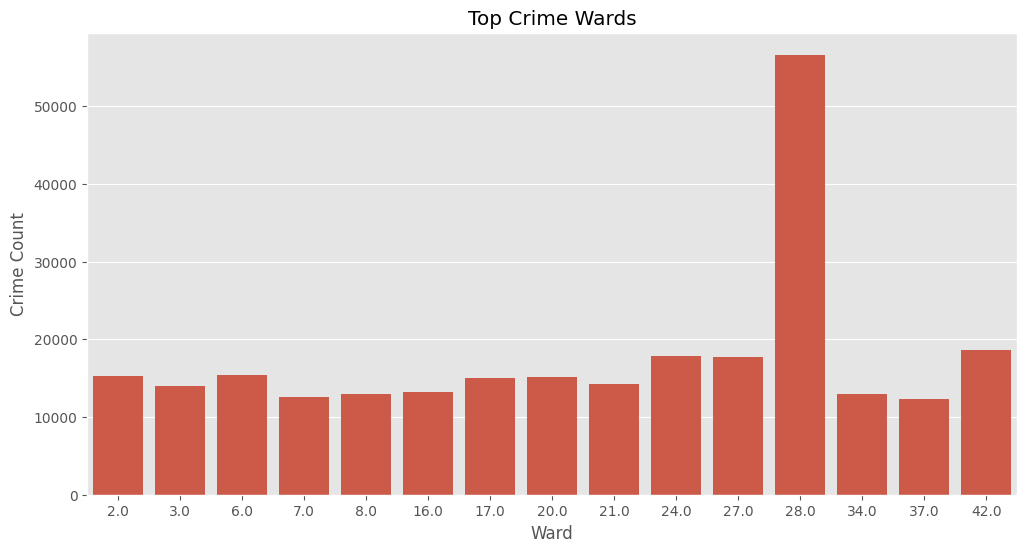

In [29]:
ward_trend = df['Ward'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=ward_trend.index, y=ward_trend.values)

plt.title("Top Crime Wards")
plt.xlabel("Ward")
plt.ylabel("Crime Count")

plt.show()

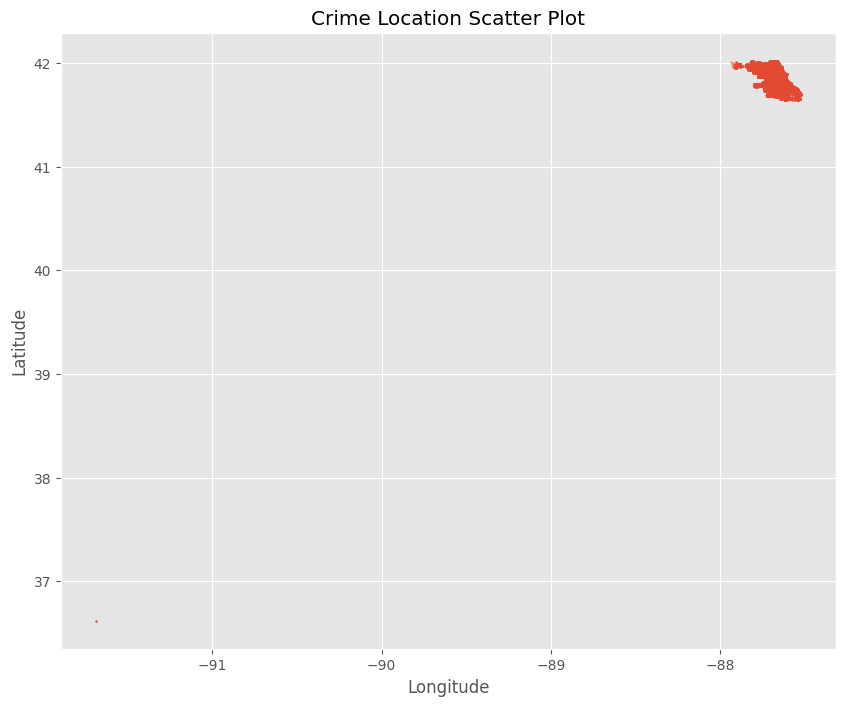

In [30]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    s=1,
    alpha=0.3
)

plt.title("Crime Location Scatter Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

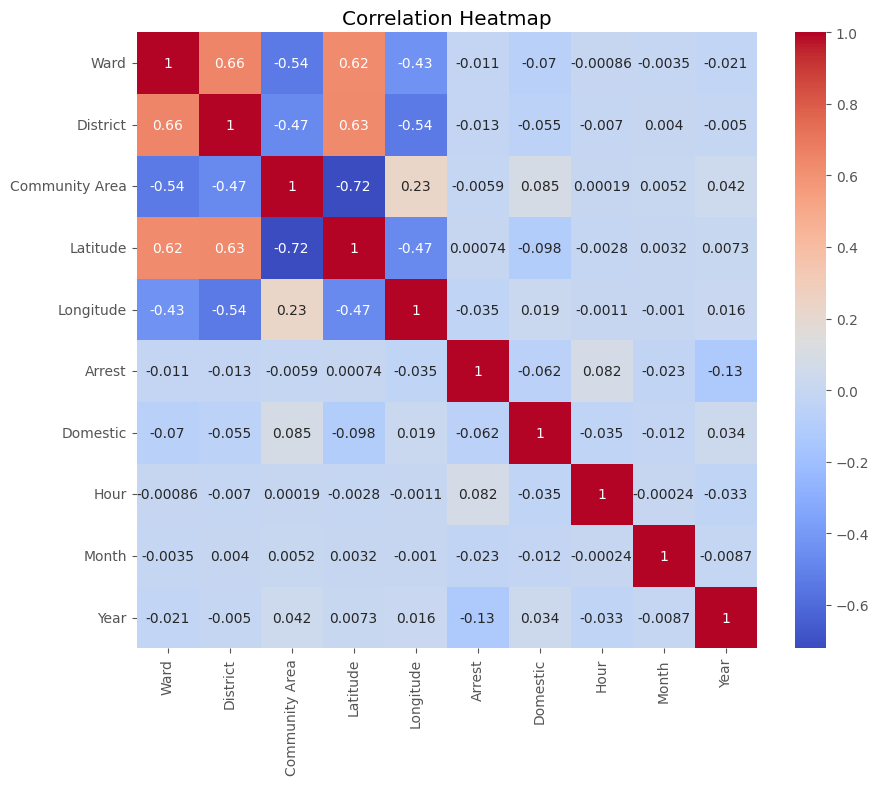

In [31]:
numeric_cols = ['Ward','District','Community Area','Latitude','Longitude','Arrest','Domestic','Hour','Month','Year']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()